# Singapore Port - Vessel Delay Prediction Model

The objectives of this project are:

* Explore historical vessel movement data.
* Identify factors associated with vessel delays.
* Build predictive machine learning models.
* Compare model performance.
* Explain the model limitations

## Importing Libraries and Loading data

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path


In [4]:
DATA_PATH = Path("Data/Singapore_anonymized.csv")

if not DATA_PATH.exists():
    raise FileNotFoundError(
        f"Dataset not found at {DATA_PATH.resolve()}."
        "Make sure Singapore_anonymized.csv dataset is in the Data folder,"
        "In the same directory as this notbook."
    )

df = pd.read_csv(DATA_PATH)
pd.set_option("display.max_columns", None)
df.head()

,MessageType,AisVersion,CallSign,Destination,DimensionA,DimensionB,DimensionC,DimensionD,Dte,EtaDay,EtaHour,EtaMinute,EtaMonth,FixType,ImoNumber,MaximumStaticDraught,MessageID,Name,RepeatIndicator,Spare,ShipType,Message.ShipStaticData.UserID,Valid,MMSI,ShipName,MetaData.latitude,MetaData.longitude,timestamp,Geom,ShipCommonDataID,Rounded_time,index,Cog,CommunicationState,Latitude,Longitude,NavigationalStatus,PositionAccuracy,Raim,RateOfTurn,speed,SpecialManoeuvreIndicator,Timestamp,TrueHeading,UserID
0,PositionReport,0.0,0,0,0.0,0.0,0.0,0.0,True,0.0,0.0,0.0,0.0,0.0,0,0.0,1,0,0,0,70.0,0,True,0,0,1.272240,103.870982,2023-10-18 19:44:50.106819454,POINT(103.87098166666667 1.27224),0,2023-10-18 19:30:00+00:00,1432.0,312.0,59916.0,1.272240,103.870982,0.0,False,False,-128.0,0.6,0.0,48.0,511.0,0
1,PositionReport,0.0,0,0,0.0,0.0,0.0,0.0,True,0.0,0.0,0.0,0.0,0.0,0,0.0,1,0,0,0,70.0,0,True,0,0,1.272245,103.870975,2023-10-18 19:45:50.126990439,POINT(103.870975 1.272245),1,2023-10-18 20:00:00+00:00,750.0,28.0,59916.0,1.272245,103.870975,0.0,False,False,-128.0,0.3,0.0,48.0,511.0,0
2,PositionReport,0.0,0,0,0.0,0.0,0.0,0.0,True,0.0,0.0,0.0,0.0,0.0,0,0.0,1,0,0,0,70.0,0,True,0,0,1.272197,103.871035,2023-10-18 20:19:50.144259386,POINT(103.87103499999999 1.2721966666666666),2,2023-10-18 20:30:00+00:00,3471.0,256.3,59916.0,1.272197,103.871035,0.0,False,False,-128.0,0.3,0.0,48.0,511.0,0
3,PositionReport,0.0,0,0,0.0,0.0,0.0,0.0,True,0.0,0.0,0.0,0.0,0.0,0,0.0,1,0,0,0,70.0,0,True,0,0,1.272190,103.871038,2023-10-18 20:48:50.789416213,POINT(103.87103833333335 1.27219),3,2023-10-18 21:00:00+00:00,3029.0,254.4,59916.0,1.272190,103.871038,0.0,False,False,-128.0,0.1,0.0,49.0,511.0,0
4,PositionReport,0.0,0,0,0.0,0.0,0.0,0.0,True,0.0,0.0,0.0,0.0,0.0,0,0.0,1,0,0,0,70.0,0,True,0,0,1.272187,103.870982,2023-10-18 22:08:59.422918477,POINT(103.87098166666667 1.2721866666666666),4,2023-10-18 22:00:00+00:00,204.0,318.9,59916.0,1.272187,103.870982,0.0,False,False,-128.0,0.2,0.0,57.0,511.0,0


## EDA

Before building predictive models, it is important to understand the quality and characteristics of the dataset.

In [4]:
df.info(verbose=True, show_counts=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 609975 entries, 0 to 609974
Data columns (total 45 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   MessageType                    609975 non-null  object 
 1   AisVersion                     609975 non-null  float64
 2   CallSign                       609975 non-null  int64  
 3   Destination                    609975 non-null  int64  
 4   DimensionA                     609975 non-null  float64
 5   DimensionB                     609975 non-null  float64
 6   DimensionC                     609975 non-null  float64
 7   DimensionD                     609975 non-null  float64
 8   Dte                            609975 non-null  bool   
 9   EtaDay                         609975 non-null  float64
 10  EtaHour                        609975 non-null  float64
 11  EtaMinute                      609975 non-null  float64
 12  EtaMonth                      

In [5]:
df.columns

Index(['MessageType', 'AisVersion', 'CallSign', 'Destination', 'DimensionA',
       'DimensionB', 'DimensionC', 'DimensionD', 'Dte', 'EtaDay', 'EtaHour',
       'EtaMinute', 'EtaMonth', 'FixType', 'ImoNumber', 'MaximumStaticDraught',
       'MessageID', 'Name', 'RepeatIndicator', 'Spare', 'ShipType',
       'Message.ShipStaticData.UserID', 'Valid', 'MMSI', 'ShipName',
       'MetaData.latitude', 'MetaData.longitude', 'timestamp', 'Geom',
       'ShipCommonDataID', 'Rounded_time', 'index', 'Cog',
       'CommunicationState', 'Latitude', 'Longitude', 'NavigationalStatus',
       'PositionAccuracy', 'Raim', 'RateOfTurn', 'speed',
       'SpecialManoeuvreIndicator', 'Timestamp', 'TrueHeading', 'UserID'],
      dtype='object')

In [6]:
df.isna().sum()

MessageType                      0
AisVersion                       0
CallSign                         0
Destination                      0
DimensionA                       0
DimensionB                       0
DimensionC                       0
DimensionD                       0
Dte                              0
EtaDay                           0
EtaHour                          0
EtaMinute                        0
EtaMonth                         0
FixType                          0
ImoNumber                        0
MaximumStaticDraught             0
MessageID                        0
Name                             0
RepeatIndicator                  0
Spare                            0
ShipType                         0
Message.ShipStaticData.UserID    0
Valid                            0
MMSI                             0
ShipName                         0
MetaData.latitude                0
MetaData.longitude               0
timestamp                        0
Geom                

In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
df.describe()

,AisVersion,CallSign,Destination,DimensionA,DimensionB,DimensionC,DimensionD,EtaDay,EtaHour,EtaMinute,EtaMonth,FixType,ImoNumber,MaximumStaticDraught,MessageID,Name,RepeatIndicator,Spare,ShipType,Message.ShipStaticData.UserID,MMSI,ShipName,MetaData.latitude,MetaData.longitude,ShipCommonDataID,index,Cog,CommunicationState,Latitude,Longitude,NavigationalStatus,RateOfTurn,speed,SpecialManoeuvreIndicator,Timestamp,TrueHeading,UserID
count,609975.000000,609975.000000,609975.000000,609975.000000,609975.000000,609975.000000,609975.000000,609975.000000,609975.000000,609975.000000,609975.000000,609975.000000,609975.000000,609975.000000,609975.000000,609975.000000,609975.0,609975.000000,609975.000000,609975.000000,609975.000000,609975.000000,609975.000000,609975.000000,609975.000000,609975.000000,609975.000000,609975.000000,609975.000000,609975.000000,609975.000000,609975.000000,609975.000000,609975.000000,609975.000000,609975.000000,609975.000000
mean,1.243766,3402.511964,1751.418050,126.895583,35.052453,13.298629,13.515775,14.628788,10.949470,12.181955,9.052076,1.640254,3334.193360,7.722992,2.348375,3373.295812,0.0,0.029375,77.804299,3396.126751,3396.126751,3379.156070,1.256576,103.840858,304987.000000,11281.991519,186.270174,60061.689276,1.256576,103.840858,1.905990,-14.667455,1.838374,0.018553,29.820802,202.364951,3396.126751
std,0.746412,1573.281184,1896.801118,71.059328,37.219132,8.215984,8.335090,9.343430,7.117417,17.137270,2.514879,2.892440,1571.823479,3.867182,0.937338,1570.984866,0.0,0.341896,5.496735,1570.010500,1570.010500,1576.199216,0.069710,0.163087,176084.759561,13024.085243,105.219249,6178.220353,0.069710,0.163087,2.524891,45.466305,6.251341,0.224391,17.564258,139.498726,1570.010500
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.0,0.000000,70.000000,0.000000,0.000000,0.000000,0.973413,102.922707,0.000000,0.000000,0.000000,59916.000000,0.973413,102.922707,0.000000,-128.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1.000000,2122.000000,61.000000,75.000000,18.000000,7.000000,7.000000,6.000000,5.000000,0.000000,10.000000,1.000000,2067.000000,5.100000,1.000000,2093.000000,0.0,0.000000,71.000000,2117.000000,2117.000000,2092.000000,1.220820,103.726217,152493.500000,1566.000000,95.000000,59916.000000,1.220820,103.726217,0.000000,0.000000,0.000000,0.000000,15.000000,88.000000,2117.000000
50%,1.000000,4024.000000,814.000000,116.000000,26.000000,12.000000,12.000000,14.000000,11.000000,0.000000,10.000000,1.000000,3979.000000,7.100000,3.000000,4011.000000,0.0,0.000000,80.000000,4014.000000,4014.000000,4018.000000,1.260418,103.828085,304987.000000,2960.000000,191.000000,59916.000000,1.260418,103.828085,1.000000,0.000000,0.000000,0.000000,30.000000,170.000000,4014.000000
75%,2.000000,4601.000000,3648.000000,172.000000,38.000000,19.000000,19.000000,23.000000,17.000000,30.000000,10.000000,1.000000,4547.000000,10.000000,3.000000,4587.000000,0.0,0.000000,80.000000,4591.000000,4591.000000,4597.000000,1.292428,103.953697,457480.500000,25955.000000,273.300000,59916.000000,1.292428,103.953697,5.000000,0.000000,0.200000,0.000000,45.000000,278.000000,4591.000000
max,3.000000,5888.000000,6160.000000,403.000000,444.000000,52.000000,60.000000,31.000000,30.000000,63.000000,13.000000,15.000000,5825.000000,25.500000,3.000000,5866.000000,0.0,6.000000,89.000000,5878.000000,5878.000000,5884.000000,2.296022,105.067017,609974.000000,36088.000000,360.000000,322060.000000,2.296022,105.067017,15.000000,127.000000,102.300000,3.000000,63.000000,511.000000,5878.000000


### Checking unique total numbers of important ship IDs

In [9]:
print(df[["CallSign", "MMSI", "ShipName", "ImoNumber"]].nunique())

CallSign     5889
MMSI         5879
ShipName     5885
ImoNumber    5826
dtype: int64


***Insights***

The IDs are not consistent. There are different total numbers of unique IDs (especially MMSI and Imo Number). It indicates that duplicate identifiers, or formatting inconsistencies across those columns.

---

***Recomendation***

Primary ID should be **IMO Number**. Because:

**IMO Number** (Most Reliable for Hull): This never changes for the life of the ship, even if it is sold or renamed. Use this if you are tracking physical ships.

**MMSI** (Best for Live Tracking/AIS): This is tied to the ship's radio equipment. It can change if the ship changes its home country flag.

**Call Sign** / Ship Name (Least Reliable): Names change frequently and are often misspelled or shared by completely different smaller boats.

---

In [10]:
df.head()

,MessageType,AisVersion,CallSign,Destination,DimensionA,DimensionB,DimensionC,DimensionD,Dte,EtaDay,EtaHour,EtaMinute,EtaMonth,FixType,ImoNumber,MaximumStaticDraught,MessageID,Name,RepeatIndicator,Spare,ShipType,Message.ShipStaticData.UserID,Valid,MMSI,ShipName,MetaData.latitude,MetaData.longitude,timestamp,Geom,ShipCommonDataID,Rounded_time,index,Cog,CommunicationState,Latitude,Longitude,NavigationalStatus,PositionAccuracy,Raim,RateOfTurn,speed,SpecialManoeuvreIndicator,Timestamp,TrueHeading,UserID
0,PositionReport,0.0,0,0,0.0,0.0,0.0,0.0,True,0.0,0.0,0.0,0.0,0.0,0,0.0,1,0,0,0,70.0,0,True,0,0,1.272240,103.870982,2023-10-18 19:44:50.106819454,POINT(103.87098166666667 1.27224),0,2023-10-18 19:30:00+00:00,1432.0,312.0,59916.0,1.272240,103.870982,0.0,False,False,-128.0,0.6,0.0,48.0,511.0,0
1,PositionReport,0.0,0,0,0.0,0.0,0.0,0.0,True,0.0,0.0,0.0,0.0,0.0,0,0.0,1,0,0,0,70.0,0,True,0,0,1.272245,103.870975,2023-10-18 19:45:50.126990439,POINT(103.870975 1.272245),1,2023-10-18 20:00:00+00:00,750.0,28.0,59916.0,1.272245,103.870975,0.0,False,False,-128.0,0.3,0.0,48.0,511.0,0
2,PositionReport,0.0,0,0,0.0,0.0,0.0,0.0,True,0.0,0.0,0.0,0.0,0.0,0,0.0,1,0,0,0,70.0,0,True,0,0,1.272197,103.871035,2023-10-18 20:19:50.144259386,POINT(103.87103499999999 1.2721966666666666),2,2023-10-18 20:30:00+00:00,3471.0,256.3,59916.0,1.272197,103.871035,0.0,False,False,-128.0,0.3,0.0,48.0,511.0,0
3,PositionReport,0.0,0,0,0.0,0.0,0.0,0.0,True,0.0,0.0,0.0,0.0,0.0,0,0.0,1,0,0,0,70.0,0,True,0,0,1.272190,103.871038,2023-10-18 20:48:50.789416213,POINT(103.87103833333335 1.27219),3,2023-10-18 21:00:00+00:00,3029.0,254.4,59916.0,1.272190,103.871038,0.0,False,False,-128.0,0.1,0.0,49.0,511.0,0
4,PositionReport,0.0,0,0,0.0,0.0,0.0,0.0,True,0.0,0.0,0.0,0.0,0.0,0,0.0,1,0,0,0,70.0,0,True,0,0,1.272187,103.870982,2023-10-18 22:08:59.422918477,POINT(103.87098166666667 1.2721866666666666),4,2023-10-18 22:00:00+00:00,204.0,318.9,59916.0,1.272187,103.870982,0.0,False,False,-128.0,0.2,0.0,57.0,511.0,0


### Numeric column distributions

array([[<Axes: title={'center': 'AisVersion'}>,
        <Axes: title={'center': 'CallSign'}>,
        <Axes: title={'center': 'Destination'}>,
        <Axes: title={'center': 'DimensionA'}>,
        <Axes: title={'center': 'DimensionB'}>,
        <Axes: title={'center': 'DimensionC'}>],
       [<Axes: title={'center': 'DimensionD'}>,
        <Axes: title={'center': 'EtaDay'}>,
        <Axes: title={'center': 'EtaHour'}>,
        <Axes: title={'center': 'EtaMinute'}>,
        <Axes: title={'center': 'EtaMonth'}>,
        <Axes: title={'center': 'FixType'}>],
       [<Axes: title={'center': 'ImoNumber'}>,
        <Axes: title={'center': 'MaximumStaticDraught'}>,
        <Axes: title={'center': 'MessageID'}>,
        <Axes: title={'center': 'Name'}>,
        <Axes: title={'center': 'RepeatIndicator'}>,
        <Axes: title={'center': 'Spare'}>],
       [<Axes: title={'center': 'ShipType'}>,
        <Axes: title={'center': 'Message.ShipStaticData.UserID'}>,
        <Axes: title={'center': 

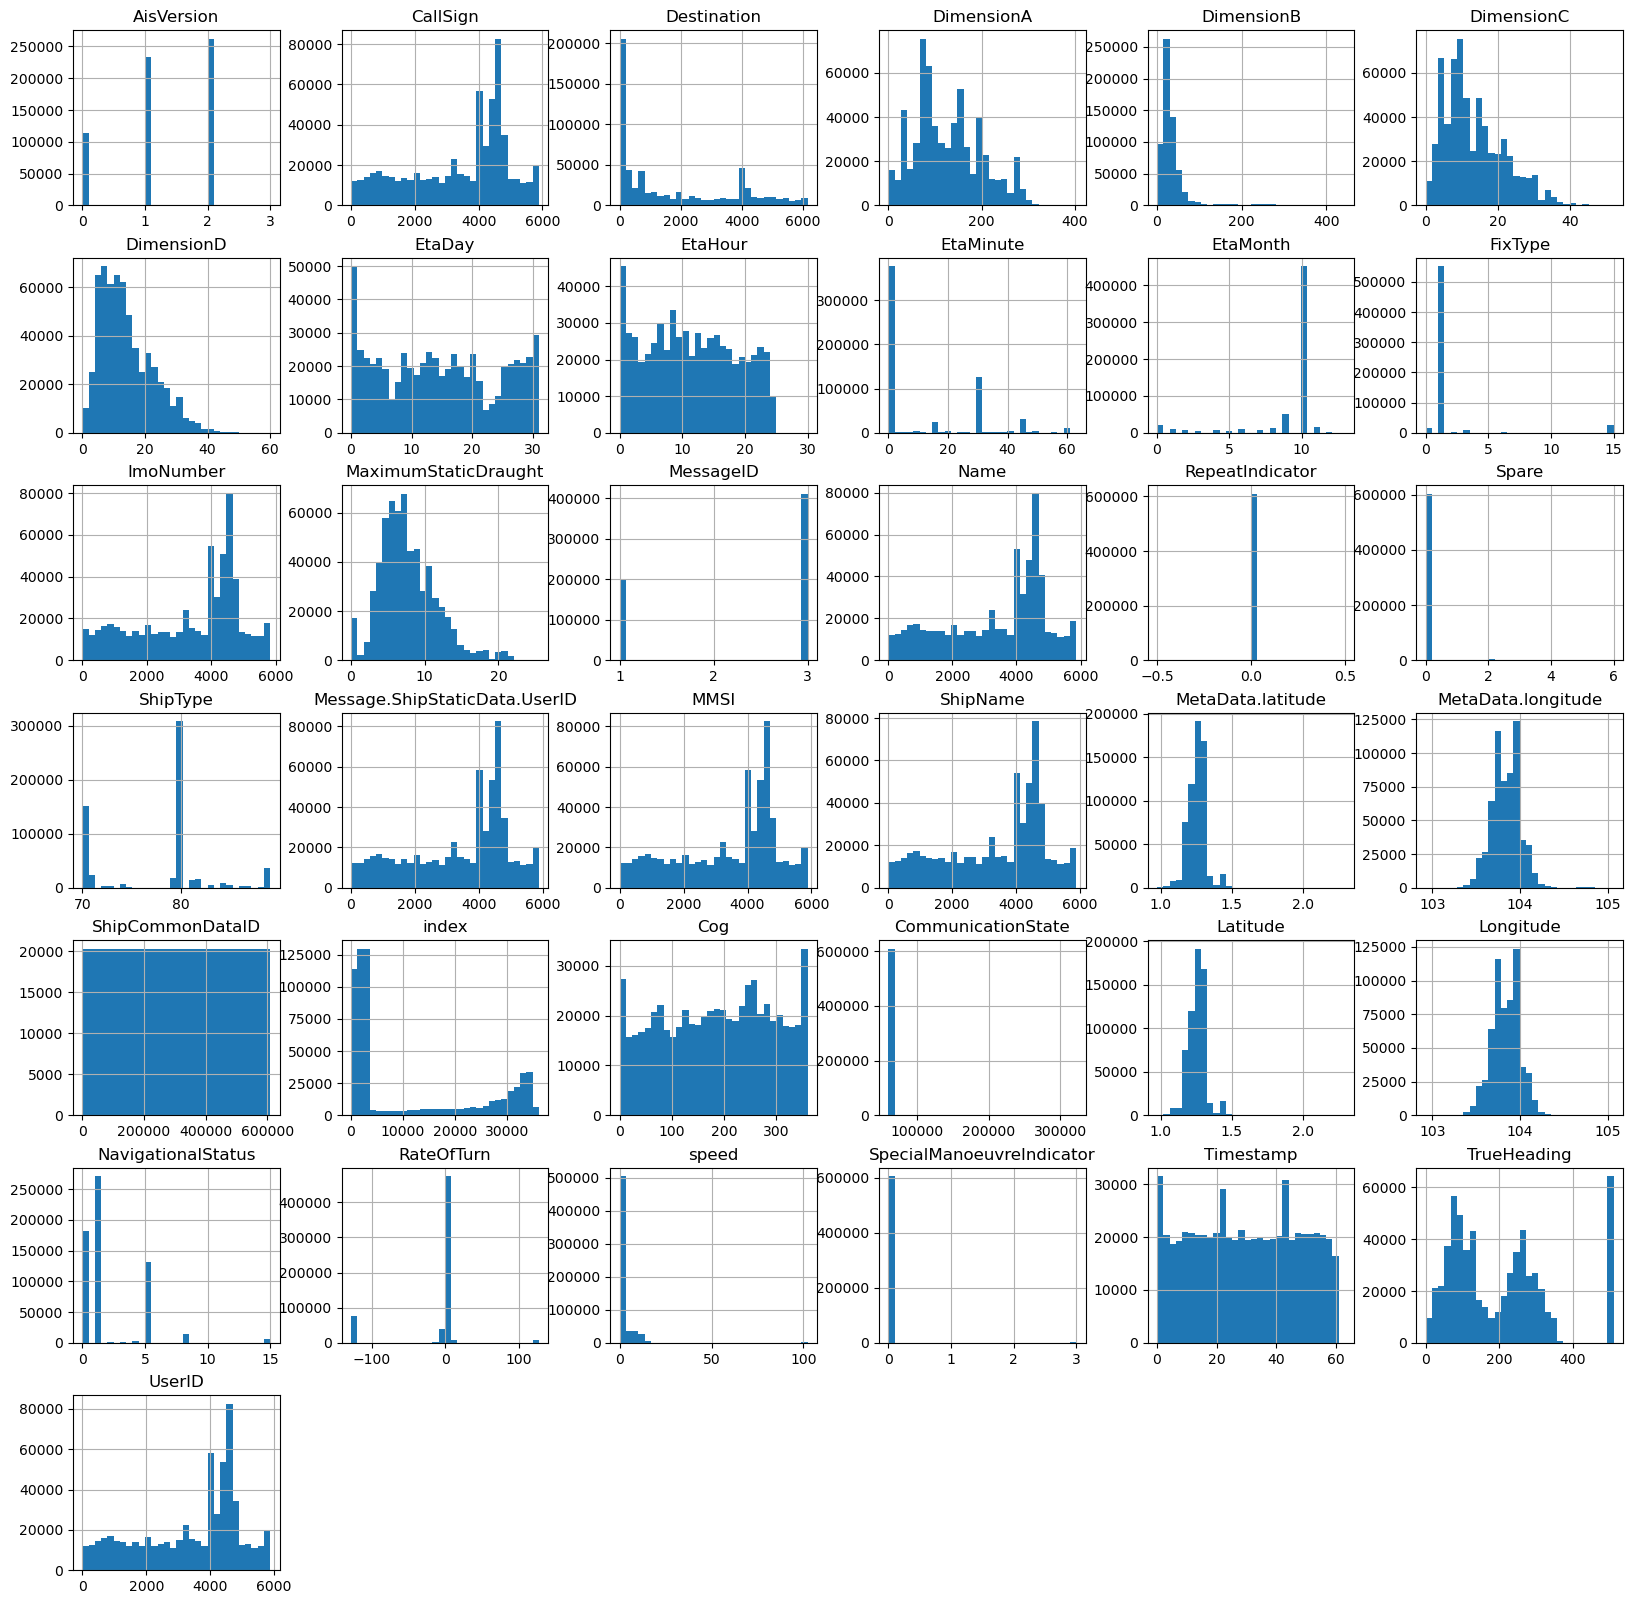

In [11]:
numeric = df.select_dtypes(include="number")

numeric.hist(
    figsize=(20,20),
    bins=30
)

***Insights***

* ETA are peak at zero.
* Predominantly cargo ships (70s) and tankers (80s)
* Inconsistent True heading overceeding 360 degree.
* Timestamp columns need to change to datetime.

## Data cleaning and manipulating for Machine Learning Model


In [12]:
df = df[df["EtaMonth"] < 13].copy()

In [13]:
df["timestamp"] = pd.to_datetime(df["timestamp"])

## Creating time-based features

In [14]:
df["Hour"] = df["timestamp"].dt.hour

df["DayOfWeek"] = df["timestamp"].dt.dayofweek

df["IsWeekend"] = df["timestamp"].dt.dayofweek >= 5


## Creating Delay column

* In order to create Delay, first we need to craft the ETA datetime.
* Some ETA columns are imputed with zero which is ETA date not available.


In [19]:
# First create blank column
df["eta_date"] = pd.NaT

# Then only rows with a valid ETA
mask = (df["EtaMonth"] > 0) & (df["EtaDay"] > 0)

df.loc[mask, "eta_date"] = pd.to_datetime(
    {
        "year": df.loc[mask, "timestamp"].dt.year,
        "month": df.loc[mask, "EtaMonth"].astype(int),
        "day": df.loc[mask, "EtaDay"].astype(int),
        "hour": df.loc[mask, "EtaHour"].astype(int),
        "minute": df.loc[mask, "EtaMinute"].astype(int),
    }
)

df[["timestamp", "eta_date"]].sample(10)

,timestamp,eta_date
17231,2023-10-13 18:13:42.641706960,2023-03-10 02:00:00
281065,2023-10-02 21:14:55.199910479,2023-10-02 05:45:00
438892,2023-10-13 03:35:00.511050779,2023-08-01 00:00:00
141670,2023-10-29 17:14:00.229810938,2023-10-29 23:30:00
96409,2023-10-17 00:07:37.594329971,2023-10-17 09:00:00
85814,2023-10-30 17:22:07.918547083,2023-10-18 07:00:00
94663,2023-10-13 12:05:33.858155452,2023-10-06 06:00:00
273375,2023-10-09 12:57:22.229012589,2023-10-09 18:00:00
9351,2023-10-04 03:46:46.499848642,2023-10-04 02:45:00
62707,2023-10-04 15:03:33.117776395,2023-10-07 01:00:00


In [24]:
# Create delay column

df["delay"] = (df["timestamp"] > df["eta_date"]).astype(bool)

print(f"\nDelay distribution:")
print(df["delay"].value_counts())
print(f"Overall delay rate: {df['delay'].mean()*100:.1f}%")


Delay distribution:
delay
True     428519
False    180949
Name: count, dtype: int64
Overall delay rate: 70.3%


## Features engineering

In [26]:
features = [
    "DayOfWeek",
    "IsWeekend",
    "Destination",
    "DimensionA",
    "DimensionB",
    "DimensionC",
    "DimensionD",
    "MaximumStaticDraught",
    "ShipType",
    "Cog",
    "Latitude",
    "Longitude",
    "NavigationalStatus",
    "speed",
    "SpecialManoeuvreIndicator"
]

target = ["delay"]

X = df[features]    
y = df[target]    

print(f"Number of features: {len(features)}")

Number of features: 15


## Importing libraries for Machine Learning

In [1]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    ConfusionMatrixDisplay,
    RocCurveDisplay
)


## Train / Test Spliting ( 80% Train, 20% test )

In [30]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"\nTraining set : {X_train.shape[0]:,} rows")
print(f"Test set     : {X_test.shape[0]:,} rows")


Training set : 487,574 rows
Test set     : 121,894 rows


## Function for Evaluating Models

In [34]:
def evaluate_model(name, y_true, y_pred):

    print("="*50)
    print(name)
    print("="*50)

    print("Accuracy :", accuracy_score(y_true, y_pred))
    print("Precision:", precision_score(y_true, y_pred))
    print("Recall   :", recall_score(y_true, y_pred))
    print("F1 Score :", f1_score(y_true, y_pred))
    print()

    print(classification_report(y_true, y_pred))

## Decision Tree

Training decision tree

In [33]:
tree = DecisionTreeClassifier(
    random_state=42
)

tree.fit(X_train, y_train)
tree_pred = tree.predict(X_test)


Evaluate decision tree model

In [ ]:
evaluate_model(
    "Decision Tree",
    y_test,
    tree_pred
)
print("ROC AOC :", roc_auc_score(y_test, tree.predict_proba(X_test)[:, 1])) 

Decision Tree
Accuracy : 0.9307595123632008
Precision: 0.9494287908048117
Recall   : 0.9522426024456269
F1 Score : 0.9508336148943854

              precision    recall  f1-score   support

       False       0.89      0.88      0.88     36190
        True       0.95      0.95      0.95     85704

    accuracy                           0.93    121894
   macro avg       0.92      0.92      0.92    121894
weighted avg       0.93      0.93      0.93    121894

ROC AOC : 0.9161086691782768


Decision Tree Features Importance

In [56]:
importance_tree = pd.DataFrame({
    "Feature": X.columns,
    "Importance": tree.feature_importances_,
}).sort_values("Importance", ascending=False).head(15)

importance_tree

,Feature,Importance
13,speed,0.177733
7,MaximumStaticDraught,0.121709
2,Destination,0.116137
11,Longitude,0.112276
10,Latitude,0.108023
3,DimensionA,0.081437
4,DimensionB,0.059763
9,Cog,0.056788
6,DimensionD,0.044170
5,DimensionC,0.039922


Feature Importance Visualization

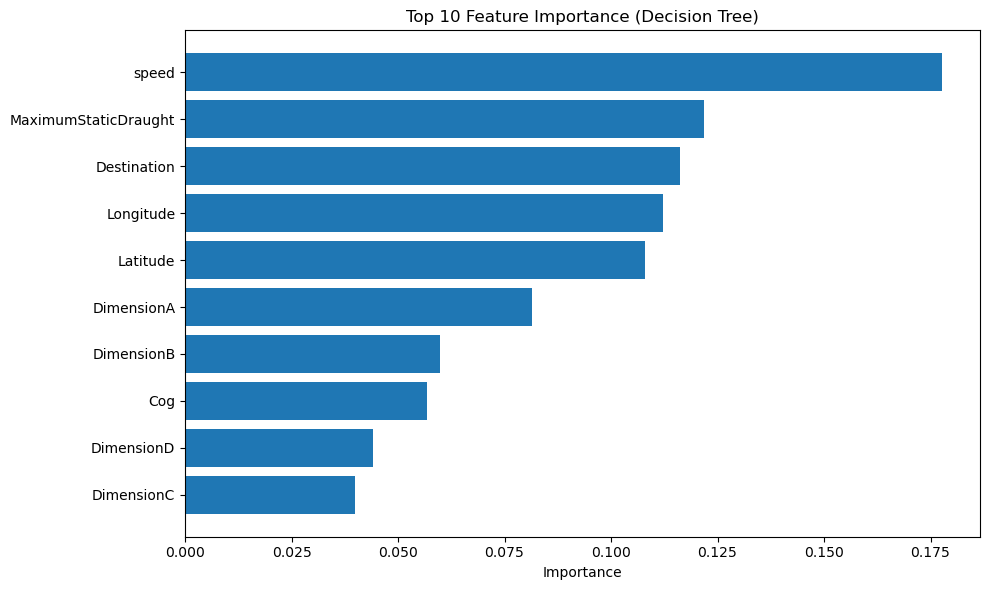

In [62]:
plt.figure(figsize=(10,6))

plt.barh(
    importance_tree["Feature"][:10],
    importance_tree["Importance"][:10]
)
plt.gca().invert_yaxis()
plt.xlabel("Importance")
plt.title("Top 10 Feature Importance (Decision Tree)")

plt.tight_layout()
plt.show()

Decision Tree Confusion matrix

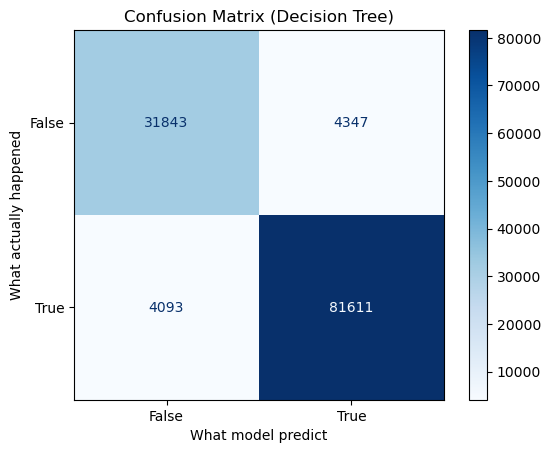

In [66]:
ConfusionMatrixDisplay.from_estimator(
    tree,
    X_test,
    y_test,
    cmap="Blues"
)
plt.title("Confusion Matrix (Decision Tree)")
plt.xlabel("What model predict")
plt.ylabel("What actually happened")
plt.show()

ROC Curve - Decision Tree

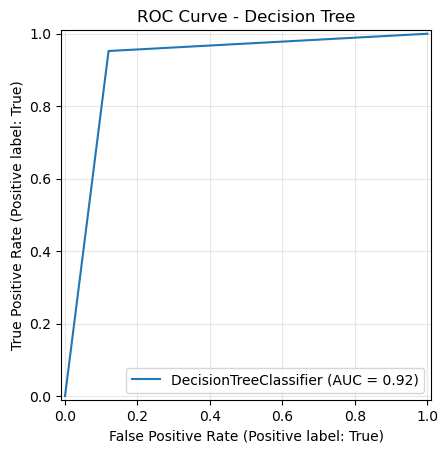

In [68]:
RocCurveDisplay.from_estimator(
    tree,
    X_test,
    y_test
)

plt.title("ROC Curve - Decision Tree")
plt.grid(alpha=0.3)
plt.show()

## Random Forest

Training random forest

In [38]:
rf = RandomForestClassifier(
    random_state=42
)

rf.fit(X_train,y_train)
rf_pred = rf.predict(X_test)


e:\Conda\Lib\site-packages\sklearn\base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


Evaluate random forest model

In [39]:
evaluate_model(
    "Random Forest",
    y_test,
    rf_pred
)
print("ROC AOC :", roc_auc_score(y_test, rf.predict_proba(X_test)[:, 1])) 

Random Forest
Accuracy : 0.9549608676390963
Precision: 0.9712815209983314
Recall   : 0.9644590684215439
F1 Score : 0.9678582719576596

              precision    recall  f1-score   support

       False       0.92      0.93      0.92     36190
        True       0.97      0.96      0.97     85704

    accuracy                           0.95    121894
   macro avg       0.94      0.95      0.95    121894
weighted avg       0.96      0.95      0.96    121894

ROC AOC : 0.9904534221089123


Random Forest Features Importance

In [54]:
importance_rf = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_,
}).sort_values("Importance", ascending=False).head(15)

importance_rf

,Feature,Importance
13,speed,0.119587
10,Latitude,0.109866
11,Longitude,0.107410
2,Destination,0.103043
7,MaximumStaticDraught,0.102418
3,DimensionA,0.077907
12,NavigationalStatus,0.069480
4,DimensionB,0.065989
9,Cog,0.063870
5,DimensionC,0.051492


Feature Importance Visualization

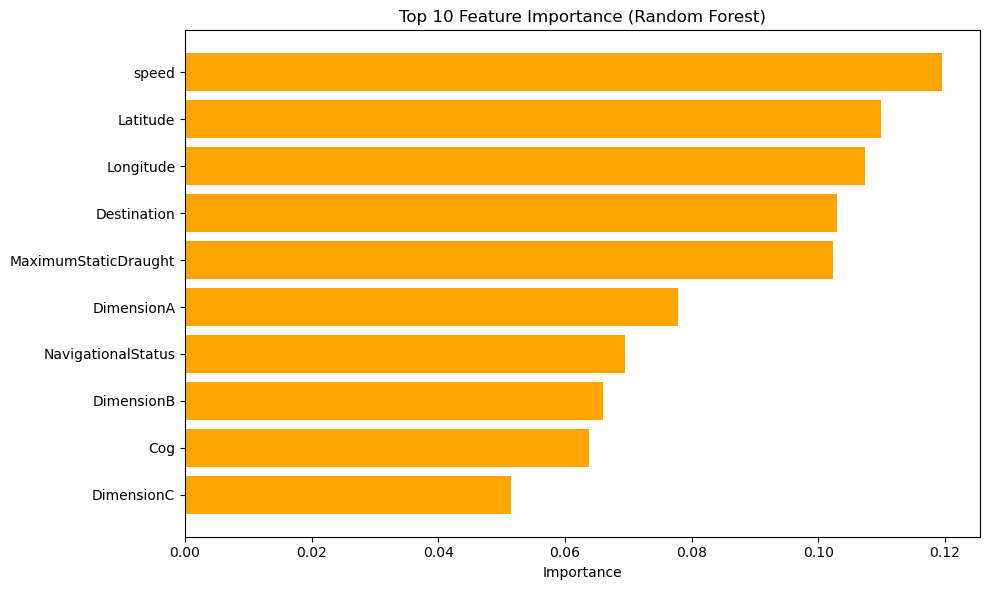

In [63]:
plt.figure(figsize=(10,6))

plt.barh(
    importance_rf["Feature"][:10],
    importance_rf["Importance"][:10],
    color="orange"
)
plt.gca().invert_yaxis()
plt.xlabel("Importance")
plt.title("Top 10 Feature Importance (Random Forest)")

plt.tight_layout()
plt.show()

Random Forest Confusion matrix

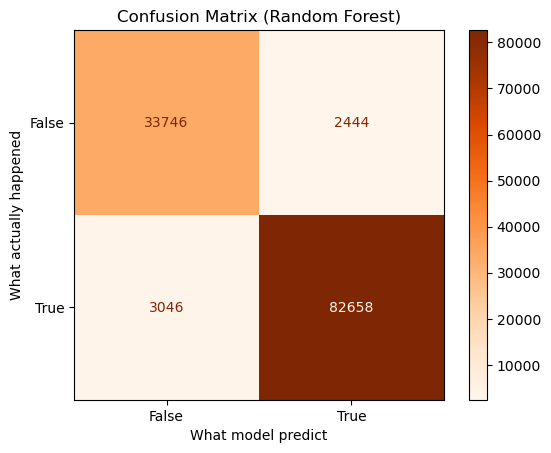

In [67]:
ConfusionMatrixDisplay.from_estimator(
    rf,
    X_test,
    y_test,
    cmap="Oranges"
)
plt.title("Confusion Matrix (Random Forest)")
plt.xlabel("What model predict")
plt.ylabel("What actually happened")
plt.show()

Random Forest ROC Curve

e:\Conda\Lib\site-packages\sklearn\utils\_plotting.py:175: FutureWarning: `**kwargs` is deprecated and will be removed in 1.9. Pass all matplotlib arguments to `curve_kwargs` as a dictionary instead.
  warnings.warn(


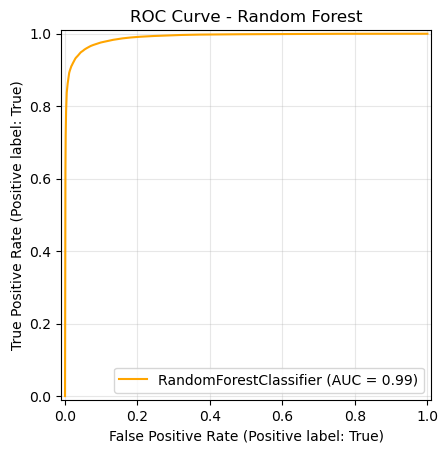

In [65]:
RocCurveDisplay.from_estimator(
    rf,
    X_test,
    y_test,
    color="orange"
)

plt.title("ROC Curve - Random Forest")
plt.grid(alpha=0.3)
plt.show()

## Model Comparison & Saving the Best Model

In [52]:
compare_table = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1 Score", "ROC AUC"],
    "Decision Tree": [
        accuracy_score(y_test, tree_pred),
        precision_score(y_test, tree_pred),
        recall_score(y_test, tree_pred),
        f1_score(y_test, tree_pred),
        roc_auc_score(y_test, tree.predict_proba(X_test)[:, 1])
    ],
    "Random Forest": [
        accuracy_score(y_test, rf_pred),
        precision_score(y_test, rf_pred),
        recall_score(y_test, rf_pred),
        f1_score(y_test, rf_pred),
        roc_auc_score(y_test, rf.predict_proba(X_test)[:, 1])
    ]
})

compare_table

,Metric,Decision Tree,Random Forest
0,Accuracy,0.930760,0.954961
1,Precision,0.949429,0.971282
2,Recall,0.952243,0.964459
3,F1 Score,0.950834,0.967858
4,ROC AUC,0.916109,0.990453


***Insights***

* Among the evaluated models, the Random Forest classifier achieved the strongest overall predictive performance, demonstrating its ability to capture complex relationships within the dataset.
* The results suggest that machine learning can support proactive decision-making in port operations by identifying vessels with a higher probability of delay before arrival.

In [69]:
import joblib

joblib.dump(rf, "singapore_port_vessel_delay_prediction_random_forest_model.pkl")

['singapore_port_vessel_delay_prediction_random_forest_model.pkl']

## Testing the Model with New Data

In [72]:
new_data = pd.DataFrame({
    "DayOfWeek": [2],
    "IsWeekend": [0],
    "Destination": [15],
    "DimensionA": [180],
    "DimensionB": [30],
    "DimensionC": [12],
    "DimensionD": [8],
    "MaximumStaticDraught": [9.5],
    "ShipType": [3],
    "Cog": [270],
    "Latitude": [1.264],
    "Longitude": [103.840],
    "NavigationalStatus": [0],
    "speed": [12.5],
    "SpecialManoeuvreIndicator": [0]
})

# Use the model you trained
prediction = rf.predict(new_data)
probability = rf.predict_proba(new_data)

print("Prediction:", prediction[0])
print("Probability of No Delay:", probability[0][0])
print("Probability of Delay:", probability[0][1])

Prediction: False
Probability of No Delay: 0.61
Probability of Delay: 0.39


## Project Limitations

This project has several limitations.

- The model relies solely on the available historical operational dataset.
- External factors such as weather, sea conditions, and unexpected port disruptions were not included.
- The prediction represents historical patterns and may not fully capture future operational changes.
- Additional operational data could further improve prediction performance.